In [3]:
import sys
import pandas as pd
sys.path.insert(0, '/Portfolio/SALES_FORCASTING/')

In [2]:
from Scripts.Model_Preprocess import ModelPrepro
# from Scripts.EDA import BASICEDA

In [4]:
df1 = pd.read_csv('../Data/train.csv')
df2 = pd.read_csv('../Data/store.csv')

C:\Users\user\AppData\Local\Temp\ipykernel_1132\3358820567.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv('../Data/train.csv')


In [6]:
df2.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [9]:
df2['StoreType'].value_counts() 

StoreType
a    602
d    348
c    148
b     17
Name: count, dtype: int64

In [6]:
preprocess = ModelPrepro(df1,df2)

In [7]:
df = preprocess.merge_store_data()

2025-05-14 13:44:30,776 - INFO - Merging training df_train with store df_train...
2025-05-14 13:44:30,939 - INFO - Merging completed. New training df_train shape: (1017209, 18)


In [8]:
df.dtypes

Store                          int64
DayOfWeek                      int64
Date                          object
Sales                          int64
Customers                      int64
Open                           int64
Promo                          int64
StateHoliday                  object
SchoolHoliday                  int64
StoreType                     object
Assortment                    object
CompetitionDistance          float64
CompetitionOpenSinceMonth    float64
CompetitionOpenSinceYear     float64
Promo2                         int64
Promo2SinceWeek              float64
Promo2SinceYear              float64
PromoInterval                 object
dtype: object

In [9]:
preprocess.data_prepro()

2025-05-14 13:44:31,060 - INFO - Starting df_train preprocessing for 1017209 rows and 18 columns.
2025-05-14 13:44:31,060 - INFO - Descriptive statistics of the df_trainset:


,count,mean,min,25%,50%,75%,max,std
Store,1017209.0,558.429727,1.0,280.0,558.0,838.0,1115.0,321.908651
DayOfWeek,1017209.0,3.998341,1.0,2.0,4.0,6.0,7.0,1.997391
Date,1017209,2014-04-11 01:30:42.846061824,2013-01-01 00:00:00,2013-08-17 00:00:00,2014-04-02 00:00:00,2014-12-12 00:00:00,2015-07-31 00:00:00,NaN
Sales,1017209.0,5773.818972,0.0,3727.0,5744.0,7856.0,41551.0,3849.926175
Customers,1017209.0,633.145946,0.0,405.0,609.0,837.0,7388.0,464.411734
Open,1017209.0,0.830107,0.0,1.0,1.0,1.0,1.0,0.375539
Promo,1017209.0,0.381515,0.0,0.0,0.0,1.0,1.0,0.485759
SchoolHoliday,1017209.0,0.178647,0.0,0.0,0.0,0.0,1.0,0.383056
CompetitionDistance,1014567.0,5430.085652,20.0,710.0,2330.0,6890.0,75860.0,7715.3237
CompetitionOpenSinceMonth,693861.0,7.222866,1.0,4.0,8.0,10.0,12.0,3.211832


##### - Generate attributes which hold the days to next holidays and to the previous holidays 

In [10]:
preprocess.days_to_next_holiday()

In [11]:
preprocess.days_after_last_holiday()

In [12]:
df = preprocess.feature_engineering()

In [13]:
preprocess.missing_percentage()

Store                         0.000000
DayOfWeek                     0.000000
Date                          0.000000
Sales                         0.000000
Customers                     0.000000
Open                          0.000000
Promo                         0.000000
StateHoliday                  0.000000
SchoolHoliday                 0.000000
StoreType                     0.000000
Assortment                    0.000000
CompetitionDistance           0.259730
CompetitionOpenSinceMonth    31.787764
CompetitionOpenSinceYear     31.787764
Promo2                        0.000000
Promo2SinceWeek              49.943620
Promo2SinceYear              49.943620
PromoInterval                49.943620
DaysToNextHoliday             6.357592
DaysAfterLastHoliday          0.109515
weekend                       0.000000
weekdays                      0.000000
Quarter                       0.000000
Month                         0.000000
Sales_lag_1                   0.000098
Sales_lag_7              

In [14]:
df.isnull().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
DaysToNextHoliday             64670
DaysAfterLastHoliday           1114
weekend                           0
weekdays                          0
Quarter                           0
Month                             0
Sales_lag_1                       1
Sales_lag_7                       7
dtype: int64

In [15]:
df = preprocess.handel_missing()

e:\Portfolio/SALES_FORCASTING\Scripts\Model_Preprocess.py:75: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  self.df_train['DaysToNextHoliday'].fillna(self.df_train['DaysToNextHoliday'].mean(), inplace=True)
e:\Portfolio/SALES_FORCASTING\Scripts\Model_Preprocess.py:76: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting v

In [16]:
df.dtypes

Store                            int64
DayOfWeek                        int64
Date                    datetime64[ns]
Sales                            int64
Customers                        int64
Open                             int64
Promo                            int64
SchoolHoliday                    int64
CompetitionDistance            float64
Promo2                           int64
DaysToNextHoliday              float64
DaysAfterLastHoliday           float64
weekend                          int64
weekdays                         int64
Quarter                          int32
Month                            int32
Sales_lag_1                    float64
Sales_lag_7                    float64
IsStateHoliday                   int64
StoreType_b                      int64
StoreType_c                      int64
StoreType_d                      int64
Assortment_b                     int64
Assortment_c                     int64
dtype: object

In [18]:
df['SchoolHoliday'].value_counts()

SchoolHoliday
0    835488
1    181721
Name: count, dtype: int64

In [19]:
df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'SchoolHoliday', 'CompetitionDistance', 'Promo2', 'DaysToNextHoliday',
       'DaysAfterLastHoliday', 'weekend', 'weekdays', 'Quarter', 'Month',
       'Sales_lag_1', 'Sales_lag_7', 'IsStateHoliday', 'StoreType_b',
       'StoreType_c', 'StoreType_d', 'Assortment_b', 'Assortment_c'],
      dtype='object')

In [22]:
df['Promo'].value_counts()

Promo
0    629129
1    388080
Name: count, dtype: int64

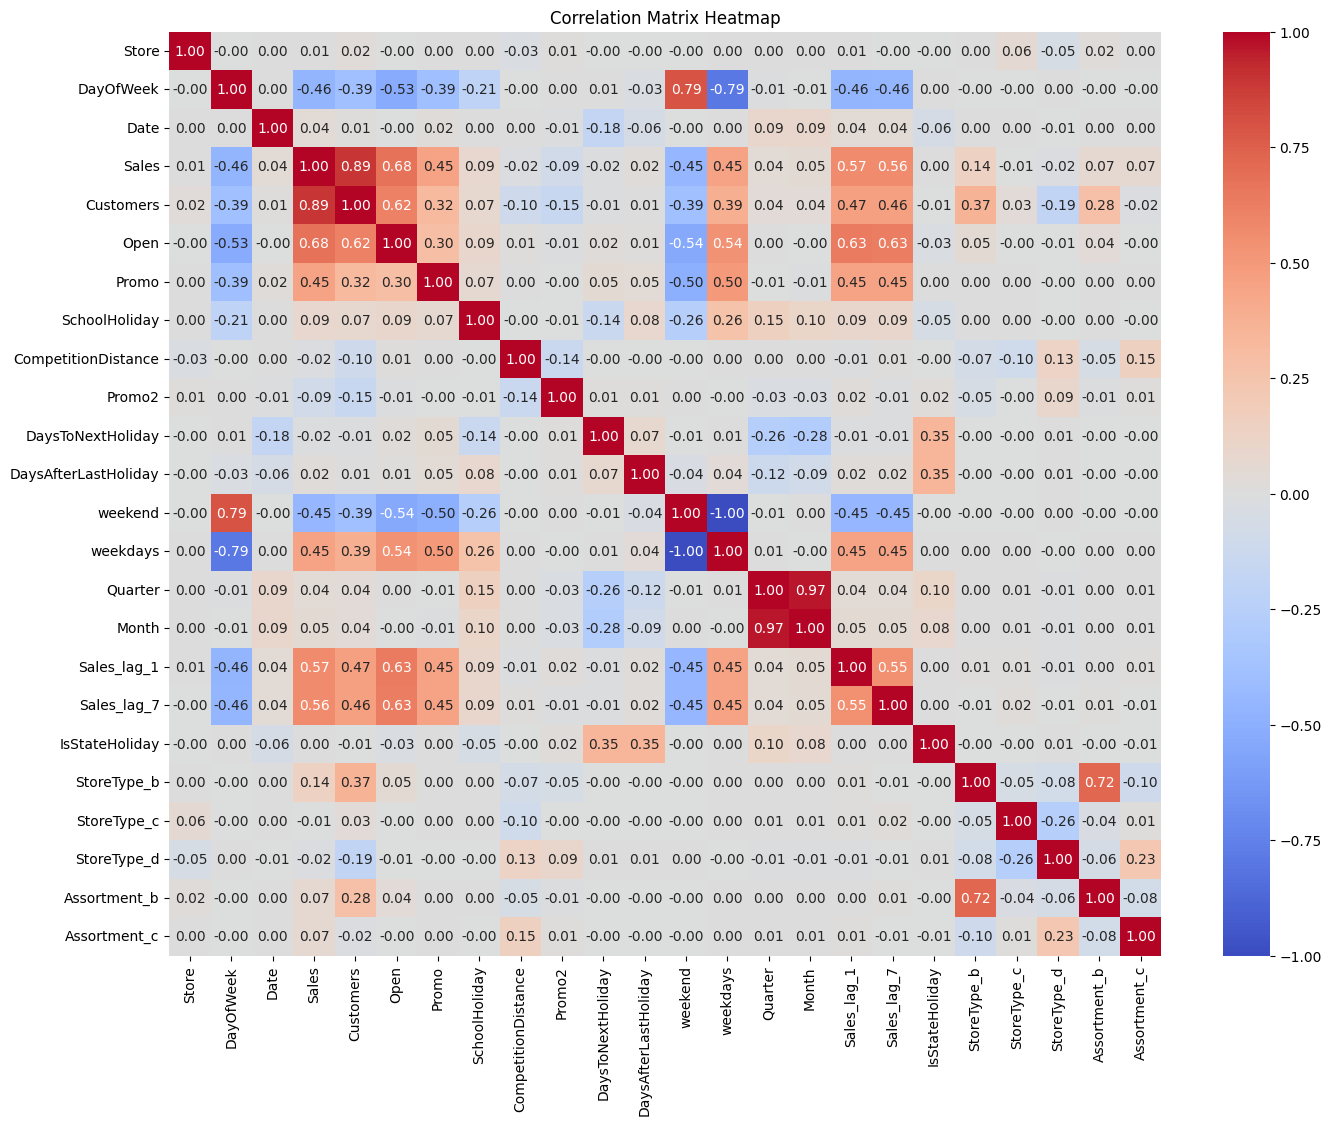

In [17]:
preprocess.salse_othe_futur_corr()

In [18]:
preprocess.scale_data()

2025-04-29 15:41:02,537 - INFO - df_train scaling complete.


,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,Promo2,DaysToNextHoliday,...,Quarter,Month,Sales_lag_1,Sales_lag_7,IsStateHoliday,StoreType_b,StoreType_c,StoreType_d,Assortment_b,Assortment_c
0,-1.731640,0.501484,-0.132683,-0.168269,0.452399,1.273237,2.144211,-0.539900,-1.001128,0.000000,...,0.652353,0.346724,0.000000,0.000000,0.384596,-0.125731,2.536447,-0.666551,-0.090668,-0.929468
1,-1.728534,0.501484,0.075373,-0.017540,0.452399,1.273237,2.144211,-0.630746,0.998873,0.000000,...,0.652353,0.346724,-0.132684,0.000000,0.384596,-0.125731,-0.394252,-0.666551,-0.090668,-0.929468
2,-1.725427,0.501484,0.659800,0.404499,0.452399,1.273237,2.144211,1.129083,0.998873,0.000000,...,0.652353,0.346724,0.075372,0.000000,0.384596,-0.125731,-0.394252,-0.666551,-0.090668,-0.929468
3,-1.722321,0.501484,2.135414,1.862258,0.452399,1.273237,2.144211,-0.624257,-1.001128,0.000000,...,0.652353,0.346724,0.659800,0.000000,0.384596,-0.125731,2.536447,-0.666551,-0.090668,1.075884
4,-1.719214,0.501484,-0.247231,-0.159656,0.452399,1.273237,2.144211,3.177025,-1.001128,0.000000,...,0.652353,0.346724,2.135415,0.000000,0.384596,-0.125731,-0.394252,-0.666551,-0.090668,-0.929468
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1.716545,-1.000476,-1.499723,-1.363330,-2.210440,-0.785400,2.144211,-0.458138,0.998873,-0.717073,...,-1.196333,-1.457193,-1.499726,-1.499745,0.384596,-0.125731,-0.394252,-0.666551,-0.090668,-0.929468
1017205,1.719651,-1.000476,-1.499723,-1.363330,-2.210440,-0.785400,2.144211,-0.460733,-1.001128,-0.717073,...,-1.196333,-1.457193,-1.499726,-1.499745,0.384596,-0.125731,2.536447,-0.666551,-0.090668,1.075884
1017206,1.722758,-1.000476,-1.499723,-1.363330,-2.210440,-0.785400,2.144211,0.497050,-1.001128,-0.717073,...,-1.196333,-1.457193,-1.499726,-1.499745,0.384596,-0.125731,-0.394252,-0.666551,-0.090668,1.075884
1017207,1.725864,-1.000476,-1.499723,-1.363330,-2.210440,-0.785400,2.144211,-0.591812,-1.001128,-0.717073,...,-1.196333,-1.457193,-1.499726,-1.499745,0.384596,-0.125731,-0.394252,-0.666551,-0.090668,1.075884
